<a href="https://www.kaggle.com/code/aamir28/ai-multi-agent-systems-2026-eda-insights?scriptVersionId=317786998" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# =============================================
# AI Multi-Agent Systems Interaction Dataset 2026
# Starter Notebook
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/aamir28/ai-multi-agent-systems-interaction-dataset-2026/ai_multi_agent_interactions_2026.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (80000, 21)


,interaction_id,timestamp,agent_id,agent_type,task_domain,task_description,collaboration_mode,agents_involved,tools_used,steps_taken,...,partial_success_score,hallucination_flag,conflict_score,energy_consumption_kwh,latency_seconds,cost_usd,model_backend,human_override,outcome_summary,iteration_count
0,INT_0000000,2025-11-24 04:03:12,AGENT_1409,Executor,Healthcare,Handle complex task in Healthcare: optimize st...,Solo,"[""AGENT_1409""]","web_search,database_query,image_gen,api_call,f...",6,...,0.83,True,0.22,0.6959,17.99,0.184,Grok-4,False,Energy optimization successful,5
1,INT_0000001,2026-01-24 05:48:46,AGENT_7924,Planner,Energy,Handle complex task in Energy: optimize strate...,Swarm,"[""AGENT_7924"", ""AGENT_2519""]","web_search,calculator,file_analysis,database_q...",5,...,0.84,False,0.37,1.0816,19.69,0.322,Gemini-2.5,False,Energy optimization successful,7
2,INT_0000002,2025-04-09 02:31:56,AGENT_1750,Critic,Energy,Handle complex task in Energy: analyze strateg...,Solo,"[""AGENT_1750""]","calculator,image_gen,api_call,code_execution",15,...,0.88,False,0.63,1.0457,49.43,0.237,Llama-4,False,Minor conflicts resolved after debate,2
3,INT_0000003,2025-07-14 09:49:42,AGENT_4598,Planner,Coding,Handle complex task in Coding: optimize system...,Swarm,"[""AGENT_4598"", ""AGENT_5386"", ""AGENT_2084"", ""AG...","file_analysis,image_gen",16,...,0.49,False,0.17,9.8879,47.66,1.883,Llama-4,False,Recursive improvement loop stabilized,4
4,INT_0000004,2025-07-05 07:59:06,AGENT_3266,DomainExpert,Creative,Handle complex task in Creative: analyze syste...,Solo,"[""AGENT_3266""]","file_analysis,code_execution",17,...,0.78,False,0.45,1.4299,51.44,0.294,Grok-4,False,Required human intervention for final decision,6


In [2]:
# Basic Information
print("=== Dataset Info ===")
print(df.info())
print("\n=== Success Rate ===")
print(df['success'].value_counts(normalize=True))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   interaction_id          80000 non-null  object 
 1   timestamp               80000 non-null  object 
 2   agent_id                80000 non-null  object 
 3   agent_type              80000 non-null  object 
 4   task_domain             80000 non-null  object 
 5   task_description        80000 non-null  object 
 6   collaboration_mode      80000 non-null  object 
 7   agents_involved         80000 non-null  object 
 8   tools_used              80000 non-null  object 
 9   steps_taken             80000 non-null  int64  
 10  success                 80000 non-null  bool   
 11  partial_success_score   80000 non-null  float64
 12  hallucination_flag      80000 non-null  bool   
 13  conflict_score          80000 non-null  float64
 14  energy_consumptio

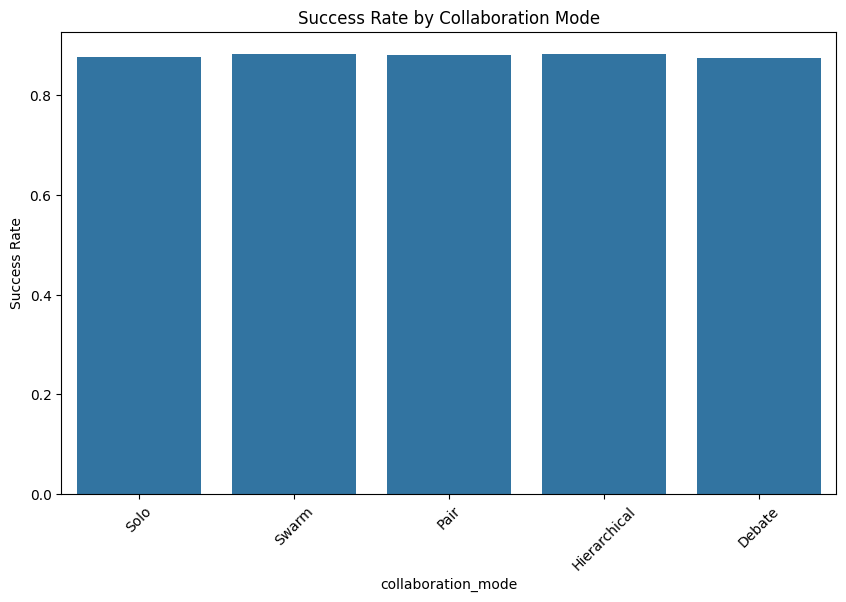

In [3]:
# 1. Success Rate by Collaboration Mode
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='collaboration_mode', y='success', estimator=np.mean, errorbar=None)
plt.title('Success Rate by Collaboration Mode')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

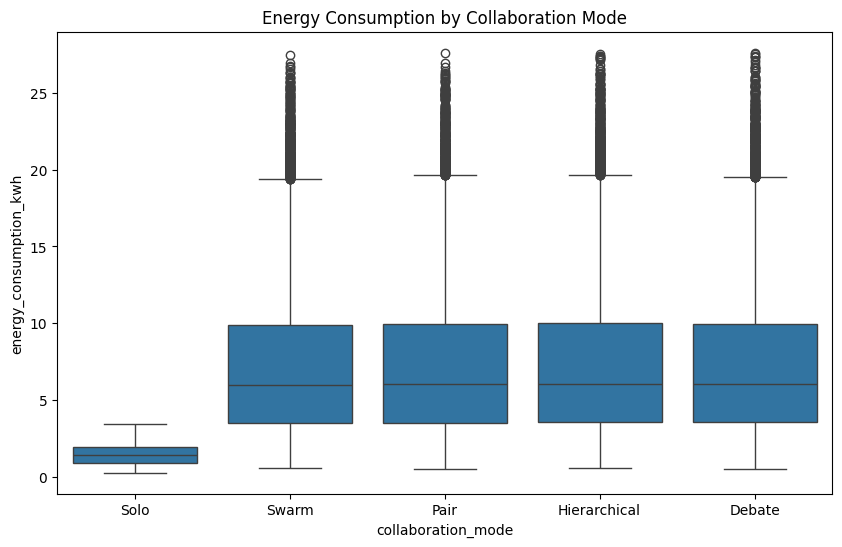

Average Energy Consumption: 6.099 kWh


In [4]:
# 2. Energy Consumption Analysis
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='collaboration_mode', y='energy_consumption_kwh')
plt.title('Energy Consumption by Collaboration Mode')
plt.show()

print("Average Energy Consumption:", df['energy_consumption_kwh'].mean().round(3), "kWh")

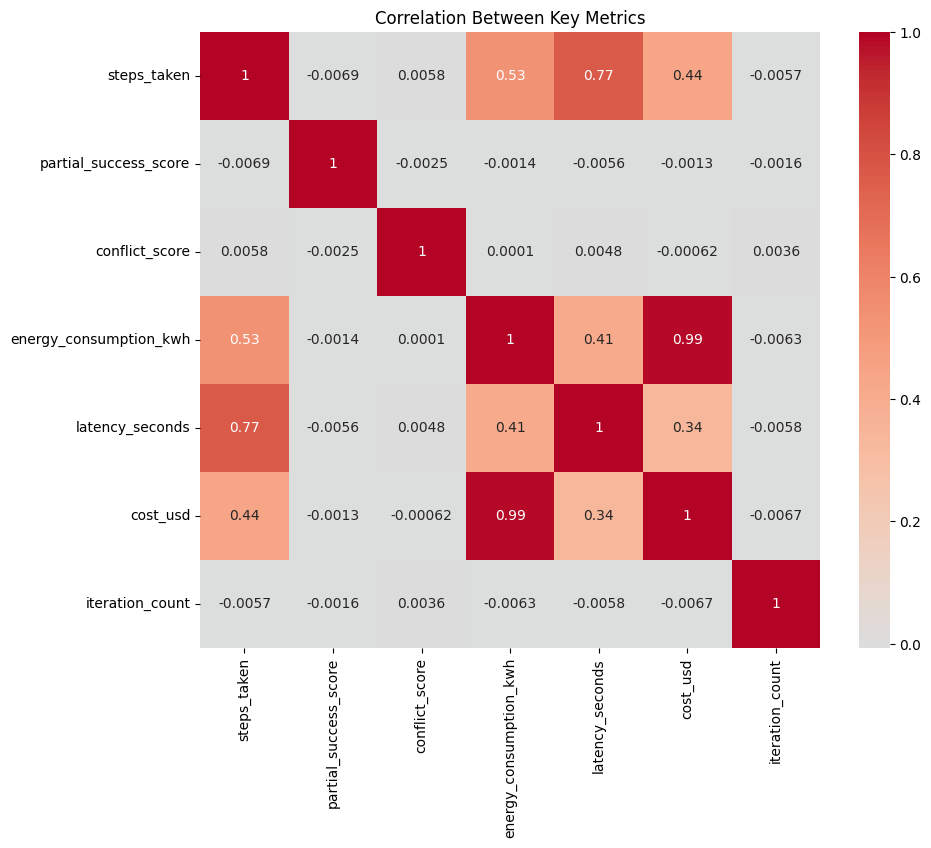

In [5]:
# 3. Correlation Analysis
numeric_cols = ['steps_taken', 'partial_success_score', 'conflict_score', 
                'energy_consumption_kwh', 'latency_seconds', 'cost_usd', 'iteration_count']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Key Metrics')
plt.show()

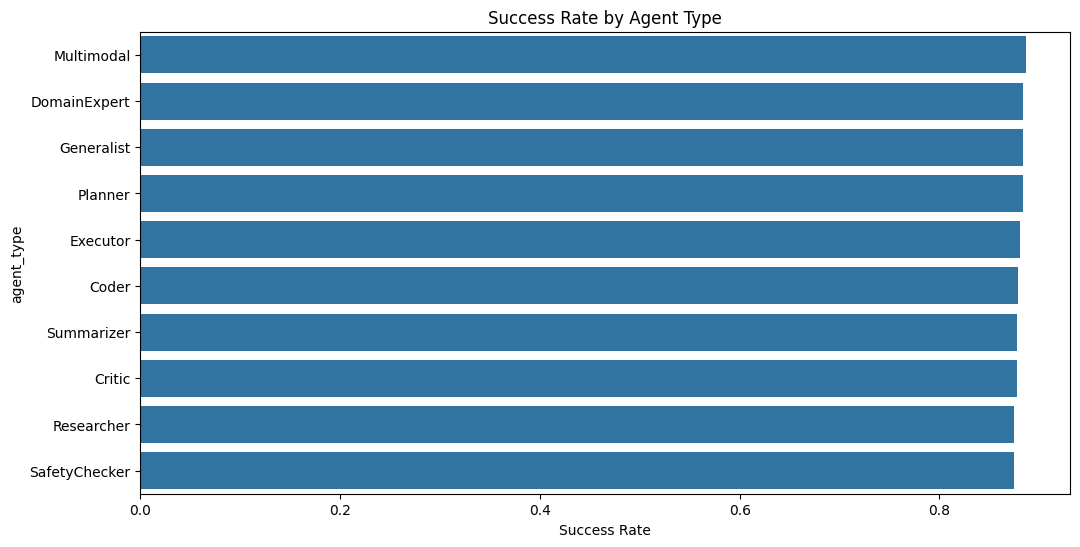

In [6]:
# 4. Top Agent Types Performance
plt.figure(figsize=(12,6))
top_agents = df.groupby('agent_type')['success'].mean().sort_values(ascending=False)
sns.barplot(x=top_agents.values, y=top_agents.index)
plt.title('Success Rate by Agent Type')
plt.xlabel('Success Rate')
plt.show()

In [7]:
# 5. Interesting Insights
print("=== Key Insights ===")
print(f"Total Interactions: {len(df):,}")
print(f"Overall Success Rate: {df['success'].mean():.1%}")
print(f"Avg Energy per Interaction: {df['energy_consumption_kwh'].mean():.3f} kWh")
print(f"Human Override Rate: {df['human_override'].mean():.1%}")
print(f"Hallucination Rate: {df['hallucination_flag'].mean():.1%}")

=== Key Insights ===
Total Interactions: 80,000
Overall Success Rate: 88.0%
Avg Energy per Interaction: 6.099 kWh
Human Override Rate: 18.0%
Hallucination Rate: 12.0%


In [8]:
# Bonus: Save a summary
summary = {
    "total_rows": len(df),
    "success_rate": float(df['success'].mean()),
    "avg_energy_kwh": float(df['energy_consumption_kwh'].mean()),
    "hallucination_rate": float(df['hallucination_flag'].mean())
}

with open('dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)